<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/Polynomial_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Polynomial Regression

if the value of degree is too small - underfitting problem

if the value of degree too large - overfit - tries to touch every point

Essentially we are finding the coefficients - degree is 1 of these coefficient and its linear therefore, **polynomial linear regression**

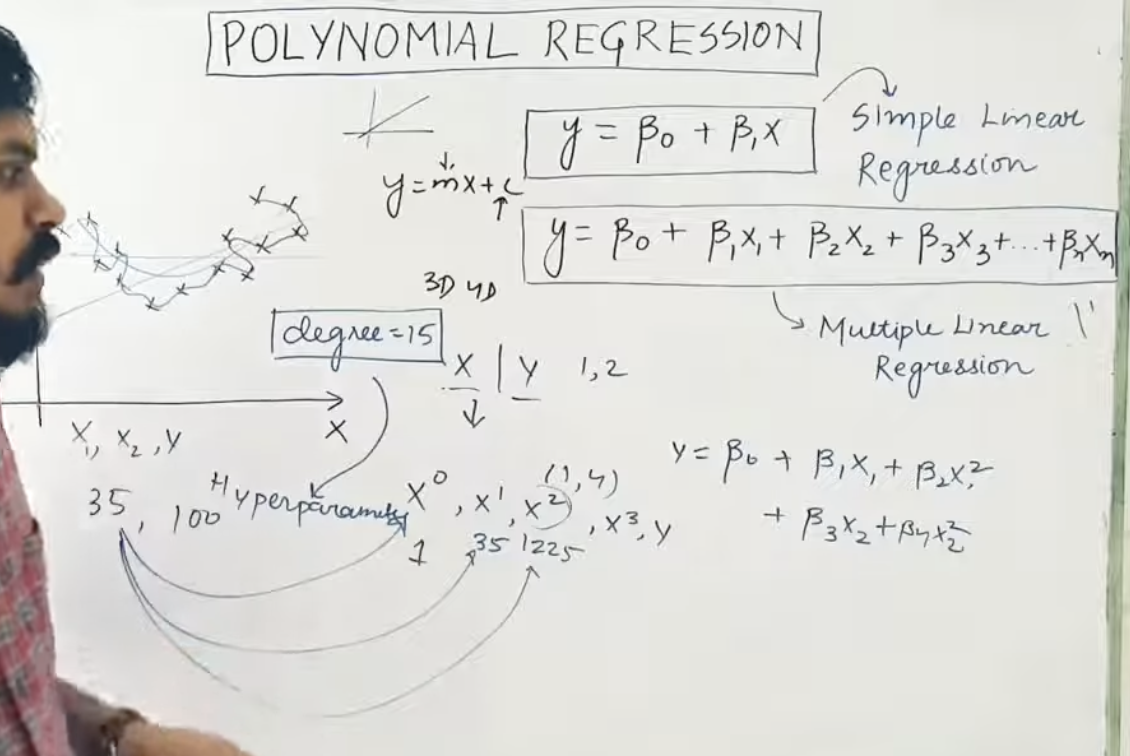

# Code

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor


from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [46]:
# Generate - Polynomial of degree 2

# 1 input col 1 output col
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200,1) # random noise added

# y = 0.8x^2 + 0.9x + 2

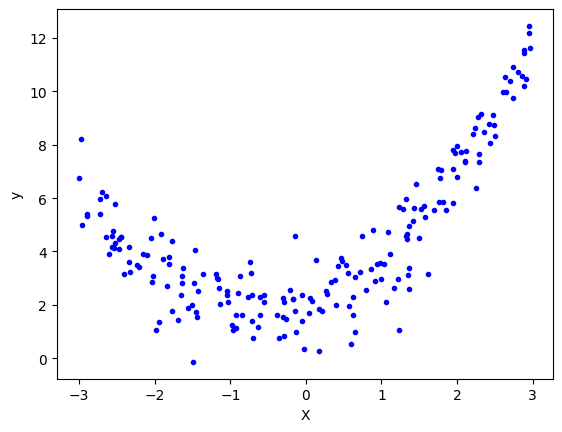

In [47]:
plt.plot(X, y, 'b. ')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [48]:
# train test splot

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Applying Linear Regression

In [49]:
# Applying Linear Regression
lr = LinearRegression()

In [50]:
lr.fit(X_train, y_train)

LinearRegression()

In [51]:
y_pred = lr.predict(X_test)

In [52]:
r2_score(y_test, y_pred)

0.08019175096457953

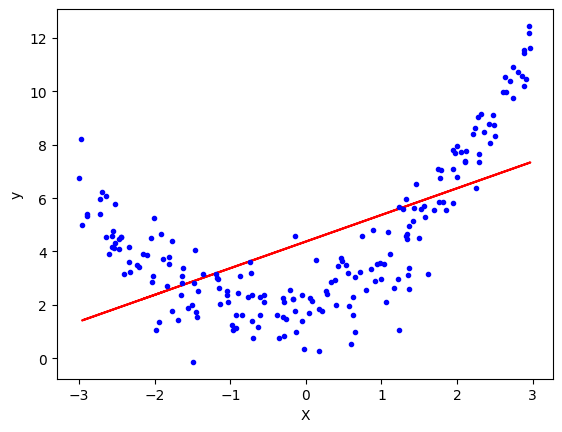

In [53]:
plt.plot(X_train, lr.predict(X_train), color='r')
plt.plot(X, y, "b. ")
plt.xlabel('X')
plt.ylabel('y')
plt.show()

# Applying Polynomial Regression

In [54]:
# Degree = 2

# apply only on input X not on y
# if u do include_bias=False it removes intercept value or bias term
poly = PolynomialFeatures(degree=2) # 1 column --> 3 columns

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [55]:
print(X_train[0])
print(X_train_trans[0])

[-2.16101226]
[ 1.         -2.16101226  4.66997397]


In [56]:
# include_bias parameter

In [57]:
lr = LinearRegression()
lr.fit(X_train_trans, y_train)

LinearRegression()

In [58]:
y_pred = lr.predict(X_test_trans)

In [59]:
r2_score(y_test, y_pred)

0.8327984313525235

In [60]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.9054072  0.77212871]]
[2.06980173]


In [61]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

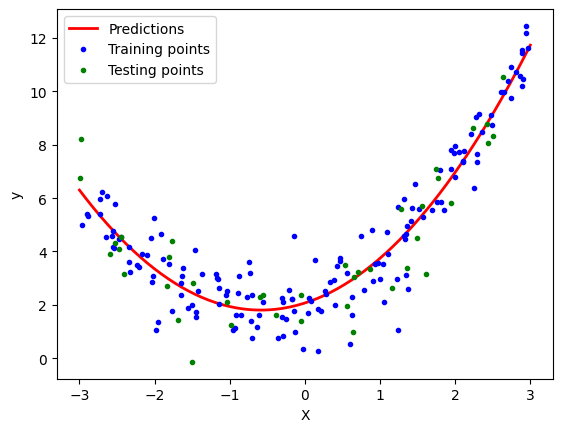

In [62]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.", label= 'Training points')
plt.plot(X_test, y_test, "g." ,label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [63]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

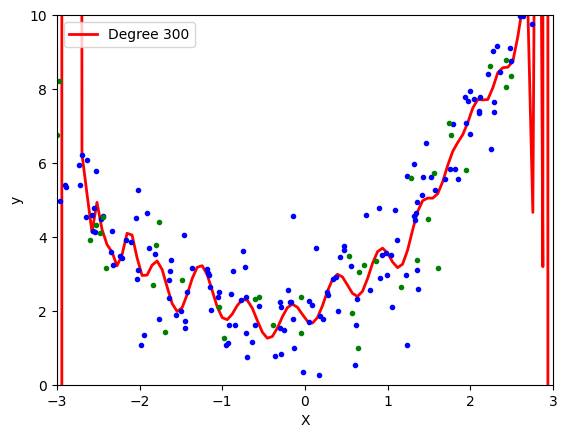

In [64]:
polynomial_regression(300) # Overfitting

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



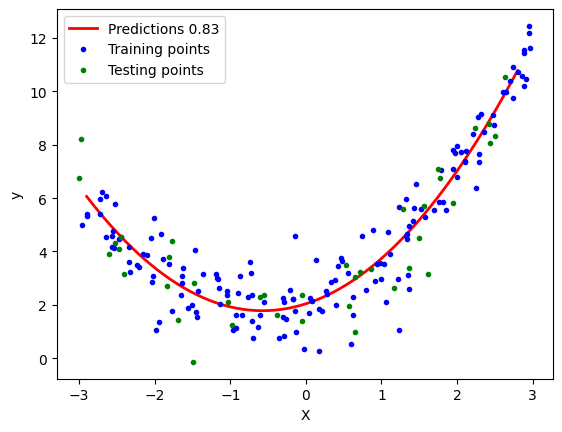

In [89]:
# Applying Gradient Descent

poly = PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

sgd = SGDRegressor(max_iter=100)
sgd.fit(X_train_trans,y_train)

X_new=np.linspace(-2.9, 2.8, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = sgd.predict(X_new_poly)

y_pred = sgd.predict(X_test_trans)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# Multiple Polynomial Regression

In [68]:
# 3D or Multiple polynomial regression

x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [69]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [71]:
# Multiple linear regression

lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

# Final
final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [72]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [73]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [82]:
poly = PolynomialFeatures(degree=6)
X_multi_trans = poly.fit_transform(X_multi)

In [83]:
print("Input",poly.n_features_in_)
print("Ouput",poly.n_output_features_)
print("Powers\n",poly.powers_)

Input 2
Ouput 28
Powers
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]
 [3 0]
 [2 1]
 [1 2]
 [0 3]
 [4 0]
 [3 1]
 [2 2]
 [1 3]
 [0 4]
 [5 0]
 [4 1]
 [3 2]
 [2 3]
 [1 4]
 [0 5]
 [6 0]
 [5 1]
 [4 2]
 [3 3]
 [2 4]
 [1 5]
 [0 6]]


In [84]:
X_multi_trans.shape

(100, 28)

In [85]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

LinearRegression()

In [86]:
X_test_multi = poly.transform(final)

In [87]:
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [88]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()